### Importing the libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Importing the dataset

In [55]:
data = pd.read_csv('shopping_Custmer_Data.csv')

In [100]:
X = data.iloc[:, [3, 4] ]

In [101]:
X

,Annual Income,Spending Score
0,151479,89
1,185088,95
2,70912,76
3,55460,57
4,153752,76
...,...,...
15074,97723,30
15075,73361,74
15076,112337,48
15077,94312,5


### Apply Feature Scaling

In [102]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

In [103]:
X

array([[ 0.79881267,  1.33705873],
       [ 1.44207552,  1.54592857],
       [-0.74320756,  0.88450743],
       ...,
       [ 0.04965041, -0.09021845],
       [-0.2953409 , -1.58711891],
       [-0.60668478, -1.69155383]])

### Now apply Elbow method 

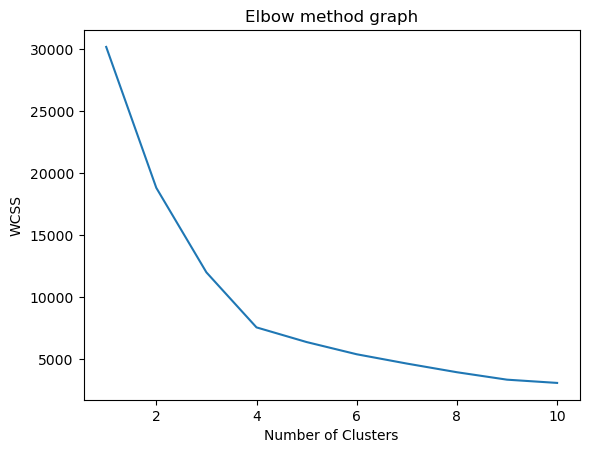

In [104]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss )
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow method graph')
plt.show()

### Train the Kmeans model

In [105]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [106]:
print(y_kmeans[:100])

[2 2 1 1 2 3 3 0 0 0 2 1 0 2 2 1 2 1 0 0 3 3 0 0 3 2 0 0 2 0 3 2 1 2 0 2 1
 1 0 1 3 1 2 0 3 2 1 0 3 0 3 0 0 2 0 0 3 0 3 2 0 1 3 0 2 0 1 2 1 3 1 3 2 3
 1 2 3 3 0 0 0 1 2 1 3 0 3 3 0 0 3 3 3 1 1 3 1 2 1 3]


### Visualising the K-means model

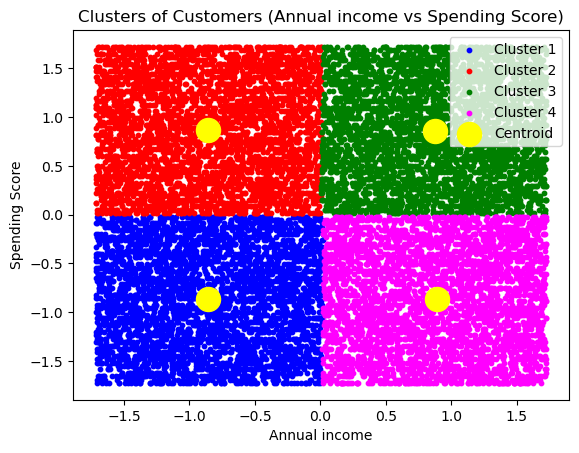

In [109]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], c = 'blue', s = 10, label = 'Cluster 1' )
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], c = 'red', s = 10, label = 'Cluster 2' )
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], c = 'green', s = 10, label = 'Cluster 3' )
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], c = 'magenta', s = 10, label = 'Cluster 4' )


plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c = 'yellow', s = 300, label = 'Centroid')
plt.title('Clusters of Customers (Annual income vs Spending Score)')
plt.xlabel('Annual income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [111]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

print("Silhouette Score:", silhouette_score(X, y_kmeans))
print("Davies-Bouldin Index:", davies_bouldin_score(X, y_kmeans))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X, y_kmeans))

Silhouette Score: 0.40620450351341364
Davies-Bouldin Index: 0.768710369422602
Calinski-Harabasz Score: 15050.610738281524


In [114]:
data[['Annual Income', 'Spending Score', 'Cluster']].groupby('Cluster').mean()

,Annual Income,Spending Score
Cluster,,
0,65147.551787,25.788193
1,64963.854541,75.503696
2,155276.082275,75.115873
3,156258.256783,25.577144


In [119]:
segment_names = {
    0: "Budget Customers",
    1: "Regular Customers",
    2: "Premium Customers",
    3: "Potential Customers"
}

data['Customer Segment'] = data['Cluster'].map(segment_names)

In [120]:
print(data[['Annual Income', 'Spending Score', 'Cluster', 'Customer Segment']].head())

   Annual Income  Spending Score  Cluster   Customer Segment
0         151479              89        2  Premium Customers
1         185088              95        2  Premium Customers
2          70912              76        1  Regular Customers
3          55460              57        1  Regular Customers
4         153752              76        2  Premium Customers


In [121]:
print(data['Customer Segment'].value_counts())

Customer Segment
Budget Customers       3862
Regular Customers      3788
Premium Customers      3780
Potential Customers    3649
Name: count, dtype: int64


In [122]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(sc, "scaler.pkl")

['scaler.pkl']